In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_1d import Tile2Symb1dBin
from image.processing import DITHER_MODES

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2Symb1dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: -0.0078 | Max: 0.0504 | Mean: 0.0244 | Std: 0.0190
Min: 0.0211 | Max: 0.1055 | Mean: 0.0714 | Std: 0.0294
Min: 0.0328 | Max: 0.1557 | Mean: 0.0899 | Std: 0.0379
Min: 0.0255 | Max: 0.1436 | Mean: 0.0790 | Std: 0.0354
Min: 0.0352 | Max: 0.1336 | Mean: 0.0812 | Std: 0.0326
Min: 0.0230 | Max: 0.1530 | Mean: 0.0761 | Std: 0.0418
Min: 0.0422 | Max: 0.1328 | Mean: 0.0798 | Std: 0.0317
Min: 0.0059 | Max: 0.1443 | Mean: 0.0715 | Std: 0.0432
Min: 0.0357 | Max: 0.1500 | Mean: 0.0878 | Std: 0.0364


C:\Users\wojte\AppData\Local\Temp\ipykernel_28020\1583207990.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


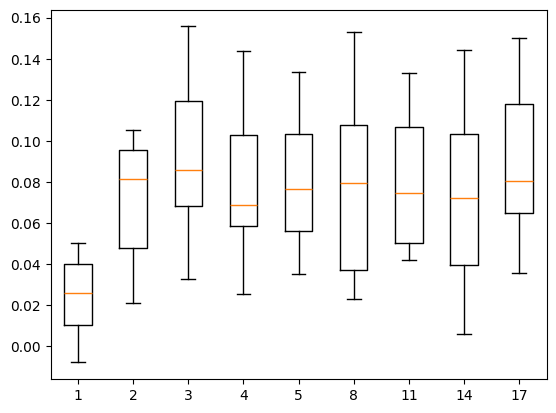

In [2]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.FS}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0245 | Max: 0.1383 | Mean: 0.0817 | Std: 0.0361
Min: 0.0242 | Max: 0.1405 | Mean: 0.0768 | Std: 0.0347
Min: 0.0311 | Max: 0.1372 | Mean: 0.0707 | Std: 0.0351
Min: 0.0263 | Max: 0.1280 | Mean: 0.0684 | Std: 0.0328
Min: 0.0128 | Max: 0.1202 | Mean: 0.0627 | Std: 0.0328


C:\Users\wojte\AppData\Local\Temp\ipykernel_28020\2815104393.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


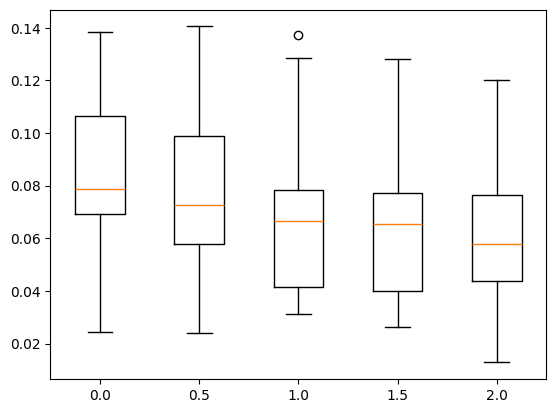

In [ ]:
# edge enhancement

edge_enhancement_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.NONE,
                         'enhance_edges': e}),
        edge_enhancement_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in edge_enhancement_vals])
plt.show()

Min: 0.0699 | Max: 0.2315 | Mean: 0.1461 | Std: 0.0559
Min: 0.0355 | Max: 0.2243 | Mean: 0.1403 | Std: 0.0541
Min: 0.0135 | Max: 0.2276 | Mean: 0.1305 | Std: 0.0601
Min: 0.0178 | Max: 0.1917 | Mean: 0.1242 | Std: 0.0527
Min: 0.0180 | Max: 0.2178 | Mean: 0.1247 | Std: 0.0616


C:\Users\wojte\AppData\Local\Temp\ipykernel_11424\3095627118.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


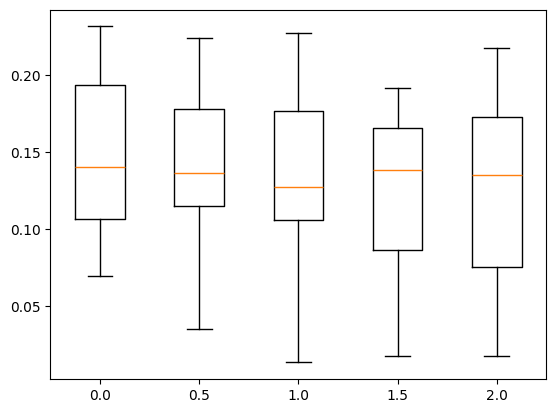

In [2]:
# edge detection

find_edges_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.NONE,
                         'find_edges': e}),
        find_edges_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in find_edges_vals])
plt.show()

In [9]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb1dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img,
                         enhance_edges=0.2,
                         find_edges=1.0,
                         quantize_colors=2, dither=DITHER_MODES.FS)
    win_w = math.ceil(MAX_WIDTH / img.width)
    win_h = win_w * 2
    if MAX_WIDTH:
        scale_w = MAX_WIDTH * win_w / img.width
    if MAX_HEIGHT:
        scale_h = MAX_HEIGHT * win_h / img.height
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    res_arr = converter.process_image(img, (win_w, win_h))
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------------
 | .`- ----------------------- | _^^_^=<|+?\^'::~;'-`.--- -; | 
 | --` `` ---.--  .------...-. | ~"_:-/<ri/*~;-~;;-:--'----- | 
 | . .` `.`.``.. ` `.```.  .`- | -;~-~=<<?i1^_~------`---`-- | 
 | - .  `.-` --` .  `  - ```.- | :---~r((!^"",--;--- --`---- | 
 | ----------------------- --- | -. `-")+<\"':'------------: | 
 | -----',---_-;---':,~--:_;;: | -_---_+>>i|^-_--,;----~-:_: | 
 | ,,_',;;---,--~-----:---'~:; | ^!^--">(<v("--;'::--_,;_~~' | 
 | !|"""^""^""^;;"^~:;,':~_;': | ^!\/|\c!ici!,:;'^^:"^;^_'," | 
 | 1^"_;;"^;-;----;;:___-----: | 1=/\\=(v+>>^"^|1/^^^^^1\1*^ | 
---------------------------------------------------------------
 | ----_-------',::_--~;;-- .- |  . ..`. `  . | 
 | ```.-..---------------. `.- |  . `  ``  `. | 
 | --- .--.--`.-----. ``` .`-- | ``.  .`.  .` | 
 | ----';"''"^^^,^^';--~'"""^_ | ``  `---. .  | 
 | --~,""^r^^^"^"^"^";"^"-:;': | ..`.;":^-`.` | 
 | ;_~:_;,---"""::;,";';---~-. |  ``.~;-,-..` | 
 |